<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/04_%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF%E1%84%87%E1%85%B5%E1%84%80%E1%85%AD_%E1%84%80%E1%85%AD%E1%84%8E%E1%85%A1%E1%84%80%E1%85%A5%E1%86%B7%E1%84%8C%E1%85%B3%E1%86%BC_%E1%84%80%E1%85%AA%E1%84%8C%E1%85%A5%E1%86%A8%E1%84%92%E1%85%A1%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 04 · 모델 비교 · 교차검증 · 과적합 이해
### "모델 성능개선 방법

**이 노트북에서 배우는 것 (실무 필수 감각)**
- 여러 머신러닝 모델을 **비교**하는 법
- **교차검증(cross-validation)**: 운(데이터 분할)에 따르지 않는 평가
- **과적합(overfitting)**: 학습데이터만 잘 맞추는 함정과 진단법
- **스케일링(전처리)·파이프라인**: 반복작업에서 빠지기 쉬운 실수 방지


In [ ]:
!pip install rdkit xgboost -q
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen

# 예제 02 의 용해도 데이터를 다시 사용 (회귀 문제)
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url).rename(columns={"measured log solubility in mols per litre":"logS"})

def featurize(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return None
    return {"MolWt":Descriptors.MolWt(m),"LogP":Crippen.MolLogP(m),
            "TPSA":Descriptors.TPSA(m),"HDonors":Descriptors.NumHDonors(m),
            "HAcceptors":Descriptors.NumHAcceptors(m),"RotBonds":Descriptors.NumRotatableBonds(m),
            "AromRings":Descriptors.NumAromaticRings(m)}
feat = df["smiles"].apply(featurize).apply(pd.Series)
data = pd.concat([feat, df["logS"]], axis=1).dropna()
X, y = data.drop(columns="logS"), data["logS"]
print("데이터:", X.shape)

데이터: (1128, 7)


## 1. ⭐ 교차검증(Cross-Validation)이란?
데이터를 한 번만 나누면, **어쩌다 쉬운/어려운 평가셋**을 뽑아 점수가 왜곡될 수 있습니다.
**K-겹 교차검증**은 데이터를 5조각으로 나눠 번갈아 평가하고 **평균**을 냅니다.

```
[1][2][3][4][5]   →  1을 평가, 2~5로 학습
[1][2][3][4][5]   →  2를 평가, 나머지로 학습  ... 5번 반복 후 평균
```
이렇게 하면 "운 좋은 점수"가 아니라 **믿을 수 있는 평균 성능**을 얻습니다.


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import KFold


# ※ 거리기반/선형 모델은 스케일링이 필요 → 파이프라인으로 묶어 데이터 누수 방지
models = {
    "선형회귀"        : make_pipeline(StandardScaler(), LinearRegression()),
    "릿지회귀"        : make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "KNN"            : make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    "랜덤포레스트"    : RandomForestRegressor(n_estimators=300, random_state=42),
    "그래디언트부스팅": GradientBoostingRegressor(random_state=42),
    "XGBoost"       : XGBRegressor(n_estimators=300, random_state=42, verbosity=0),
}

scores = {}
for name, m in models.items():
    # 5겹 교차검증, R² 기준 (5개 점수의 평균과 표준편차)
    # cv = cross_val_score(m, X, y, cv=5, scoring="r2")
    # 실전에서는 KFold를 사용하여 데이터를 섞는 것이 안전
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv = cross_val_score(m, X, y, cv=kf, scoring="r2")
    scores[name] = cv
    print(f"{name:14s}  R² = {cv.mean():.3f} ± {cv.std():.3f}")

선형회귀            R² = 0.782 ± 0.014
릿지회귀            R² = 0.782 ± 0.014
KNN             R² = 0.860 ± 0.013
랜덤포레스트          R² = 0.884 ± 0.017
그래디언트부스팅        R² = 0.879 ± 0.011
XGBoost         R² = 0.876 ± 0.015


In [ ]:

# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# 모델별 교차검증 점수를 상자그림으로 비교 (분포가 높고 좁을수록 좋은 모델)
plt.figure(figsize=(8,4))
plt.boxplot(scores.values(), labels=scores.keys(), vert=True)
plt.ylabel("R² (5겹 교차검증)"); plt.xticks(rotation=30, ha="right")
plt.title("모델 비교"); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,244 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


NameError: name 'scores' is not defined

<Figure size 800x400 with 0 Axes>

## 2. ⭐ 과적합(Overfitting) 진단
과적합 = **학습데이터는 잘 맞추지만, 새 데이터는 못 맞추는** 상태.  

트리모델의 경우 트리의 깊이(depth)를 키워가며 **학습 점수 vs 검증 점수**를 비교하면 과적합이 눈에 보입니다.


In [ ]:
from sklearn.model_selection import validation_curve
depths = range(1, 21)
train_sc, val_sc = validation_curve(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X, y, param_name="max_depth", param_range=depths, cv=5, scoring="r2")

plt.figure(figsize=(7,4))
plt.plot(depths, train_sc.mean(1), "o-", label="학습 점수")
plt.plot(depths, val_sc.mean(1), "s-", label="검증 점수")
plt.xlabel("트리 최대 깊이 (모델 복잡도 →)"); plt.ylabel("R²")
plt.title("복잡도가 커지면 학습↑ 하지만 검증은 정체 = 과적합 신호")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("→ 두 곡선의 간격이 벌어지는 지점이 과적합. 검증 점수가 최고인 깊이를 선택.")

NameError: name 'RandomForestRegressor' is not defined

## 3. 학습곡선 — "데이터를 더 모으면 좋아질까?"
데이터 양을 늘려가며 성능 변화를 보면, **데이터를 더 모을 가치가 있는지** 판단할 수 있습니다.
(현장에서 '실험을 더 할지' 결정할 때 유용)


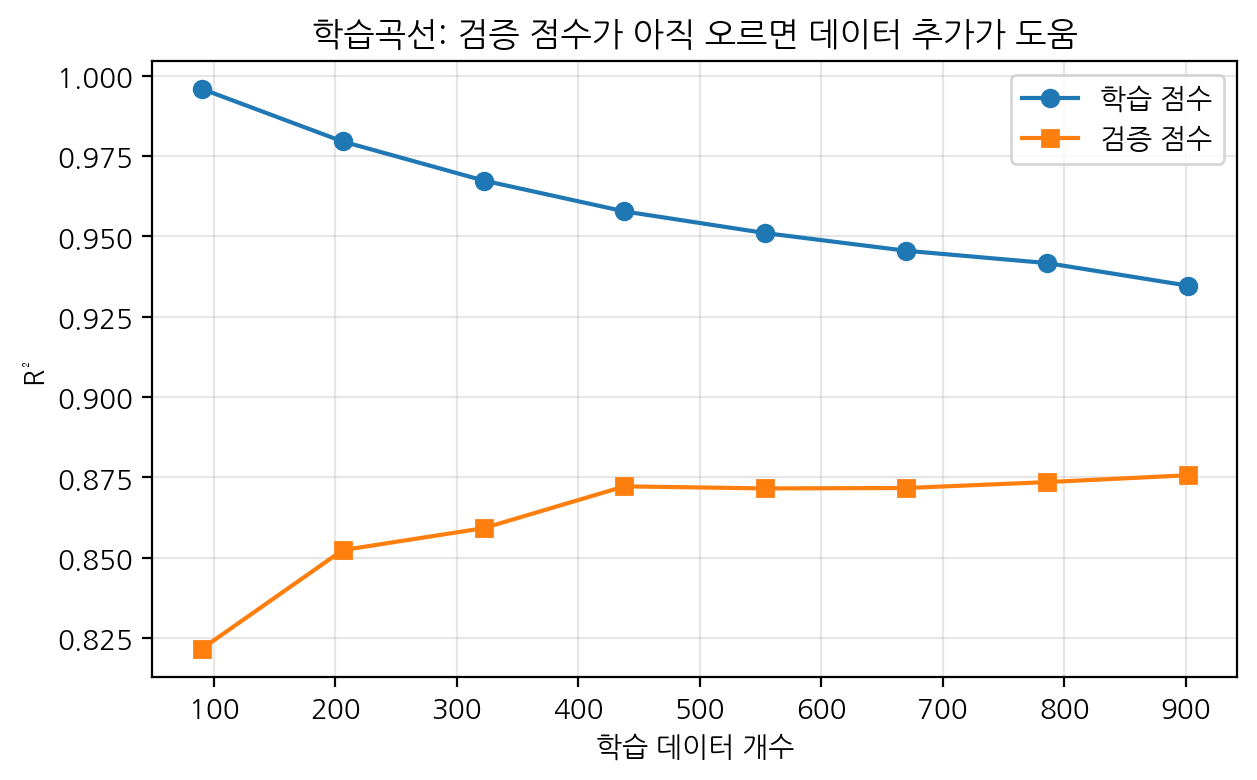

In [ ]:
from sklearn.model_selection import learning_curve
sizes, tr, va = learning_curve(
    GradientBoostingRegressor(random_state=42), X, y,
    train_sizes=np.linspace(0.1,1.0,8), cv=5, scoring="r2")

plt.figure(figsize=(7,4))
plt.plot(sizes, tr.mean(1), "o-", label="학습 점수")
plt.plot(sizes, va.mean(1), "s-", label="검증 점수")
plt.xlabel("학습 데이터 개수"); plt.ylabel("R²")
plt.title("학습곡선: 검증 점수가 아직 오르면 데이터 추가가 도움"); plt.legend()
plt.grid(alpha=0.3); plt.show()

## 4. 하이퍼파라미터 튜닝 (GridSearch)
모델의 설정값(하이퍼파라미터) 경우의 수를 모두 탐색해 **최적 조합**을 찾습니다.  
실전에서는 Random Search를 사용합니다


In [ ]:
from sklearn.model_selection import GridSearchCV
grid = {
    "n_estimators": [100, 300],
    "max_depth"   : [3, 5, 8],
    "learning_rate": [0.05, 0.1],
}
gs = GridSearchCV(GradientBoostingRegressor(random_state=42),
                  grid, cv=5, scoring="r2", n_jobs=-1)
gs.fit(X, y)
print("최적 설정:", gs.best_params_)
print("최고 교차검증 R²:", round(gs.best_score_, 3))

최적 설정: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
최고 교차검증 R²: 0.885


## 정리 — 실무 체크리스트
1. **한 번의 분할을 믿지 말 것** → 교차검증으로 평균±표준편차 보고
2. **스케일링 필요한 모델은 파이프라인**으로 묶어 데이터 누수 방지
3. **학습≫검증** 이면 과적합 → 모델 단순화 / 정규화 / 데이터 추가
4. **여러 모델을 공정 비교** 후, 필요시 GridSearch 로 튜닝